<a href="https://colab.research.google.com/github/N17-R4M/bigdata-lab-FFLM/blob/main/Analise_Explorat%C3%B3ria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto de Big Data: Análise do Exame Nacional (2024)

Este notebook apresenta a etapa de Análise Exploratória de Dados (EDA) e Limpeza das bases do exame.
Para garantir a colaboração e evitar limitações de memória, os dados estão hospedados no Google Drive, permitindo que toda a nova equipe acesse a mesma fonte de dados de forma sincronizada.

### 🚩 Nota para a Equipe (Setup do Ambiente)

Para que este notebook funcione perfeitamente na máquina de qualquer membro do grupo, sigam estes passos:
1. Abram o e-mail neutro do projeto e acessem o Google Drive compartilhado.
2. Garantam que os arquivos `PARTICIPANTES_2024.csv`, `RESULTADOS_2024.csv` e `ITENS_PROVA_2024.csv` estão salvos dentro de uma pasta chamada `Projeto_ENEM` no Drive.
3. Ao executar a primeira célula deste código, o Colab pedirá permissão para acessar o Drive. Basta autorizar e rodar o resto do notebook!

Etapa de ingestão e limpeza dos Dados


In [25]:
# Ingestão e Processamento

import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", palette="muted")

drive.mount('/content/drive')
caminho_drive = '/content/drive/MyDrive/Projeto_ENEM/'

# Lendo com o separador correto e ignorando a base de Itens
# O parâmetro low_memory=False ajuda com bases grandes onde o Pandas se perde nos tipos de dados
df_participantes = pd.read_csv(caminho_drive + 'PARTICIPANTES_2024.csv', sep=';', encoding='latin1', low_memory=False)
df_resultados = pd.read_csv(caminho_drive + 'RESULTADOS_2024.csv', sep=';', encoding='latin1', low_memory=False)

print(f"Participantes carregados: {df_participantes.shape[0]} linhas e {df_participantes.shape[1]} colunas.")
print(f"Resultados carregados: {df_resultados.shape[0]} linhas e {df_resultados.shape[1]} colunas.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Participantes carregados: 4332944 linhas e 38 colunas.
Resultados carregados: 4332944 linhas e 42 colunas.


In [26]:
#Verificação das colunas das bases
print(df_participantes.columns.tolist())
print("\n")
print(df_resultados.columns.tolist())

['NU_INSCRICAO', 'NU_ANO', 'TP_FAIXA_ETARIA', 'TP_SEXO', 'TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'TP_ST_CONCLUSAO', 'TP_ANO_CONCLUIU', 'TP_ENSINO', 'IN_TREINEIRO', 'CO_MUNICIPIO_PROVA', 'NO_MUNICIPIO_PROVA', 'CO_UF_PROVA', 'SG_UF_PROVA', 'Q001', 'Q002', 'Q003', 'Q004', 'Q005', 'Q006', 'Q007', 'Q008', 'Q009', 'Q010', 'Q011', 'Q012', 'Q013', 'Q014', 'Q015', 'Q016', 'Q017', 'Q018', 'Q019', 'Q020', 'Q021', 'Q022', 'Q023']


['NU_SEQUENCIAL', 'NU_ANO', 'CO_ESCOLA', 'CO_MUNICIPIO_ESC', 'NO_MUNICIPIO_ESC', 'CO_UF_ESC', 'SG_UF_ESC', 'TP_DEPENDENCIA_ADM_ESC', 'TP_LOCALIZACAO_ESC', 'TP_SIT_FUNC_ESC', 'CO_MUNICIPIO_PROVA', 'NO_MUNICIPIO_PROVA', 'CO_UF_PROVA', 'SG_UF_PROVA', 'TP_PRESENCA_CN', 'TP_PRESENCA_CH', 'TP_PRESENCA_LC', 'TP_PRESENCA_MT', 'CO_PROVA_CN', 'CO_PROVA_CH', 'CO_PROVA_LC', 'CO_PROVA_MT', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'TX_RESPOSTAS_CN', 'TX_RESPOSTAS_CH', 'TX_RESPOSTAS_LC', 'TX_RESPOSTAS_MT', 'TP_LINGUA', 'TX_GABARITO_CN', 'TX_GABARITO_CH', '

In [27]:
# Força o Pandas a mostrar TODAS as colunas no display
pd.set_option('display.max_columns', None)

print("🔍 VISUALIZAÇÃO: BASE DE PARTICIPANTES (Primeiras e Últimas 5 linhas)")
# Concatenamos o head() e o tail() para ver os extremos da tabela de uma vez
display(pd.concat([df_participantes.head(), df_participantes.tail()]))

print("\n" + "="*80 + "\n")

print("🔍 VISUALIZAÇÃO: BASE DE RESULTADOS (Primeiras e Últimas 5 linhas)")
display(pd.concat([df_resultados.head(), df_resultados.tail()]))

# Opcional: Resetar a configuração para o padrão do Pandas depois de visualizar
pd.reset_option('display.max_columns')

🔍 VISUALIZAÇÃO: BASE DE PARTICIPANTES (Primeiras e Últimas 5 linhas)


,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023
0,210062064233,2024,5,F,1,1,1,1,3,NaN,0,4314902,Porto Alegre,43,RS,F,F,C,D,4,B,C,A,C,D,C,B,B,A,B,B,B,D,A,B,B,E,A
1,210062064234,2024,11,F,1,1,1,1,10,NaN,0,4318903,São Luiz Gonzaga,43,RS,B,C,A,D,2,B,E,A,B,B,B,B,B,A,A,A,A,B,A,B,A,C,A
2,210062064235,2024,11,F,1,1,1,1,9,NaN,0,4320107,Sarandi,43,RS,H,F,F,D,5,B,J,A,C,D,B,B,C,A,B,B,B,D,B,B,A,D,A
3,210062064236,2024,3,F,1,3,1,2,0,1.0,0,4313409,Novo Hamburgo,43,RS,B,B,B,B,6,A,C,A,B,C,B,A,B,A,B,A,A,A,A,B,A,D,A
4,210062064237,2024,16,M,3,1,1,1,18,NaN,0,4309209,Gravataí,43,RS,B,B,C,C,2,A,A,A,B,C,A,A,B,A,A,A,A,B,A,B,A,B,A
4332939,210066495575,2024,7,M,1,1,1,1,2,NaN,0,4314407,Pelotas,43,RS,A,B,F,B,4,A,C,A,C,B,A,A,B,A,B,A,A,B,A,B,A,C,A
4332940,210066495576,2024,6,M,1,3,1,3,0,NaN,1,4314407,Pelotas,43,RS,B,C,B,F,3,B,C,A,B,C,B,B,B,A,A,A,A,C,A,B,A,C,A
4332941,210066495577,2024,4,F,1,2,1,1,1,NaN,0,3518800,Guarulhos,35,SP,E,E,C,D,5,A,E,A,B,C,B,A,B,A,B,B,A,B,A,B,B,B,A
4332942,210066495578,2024,2,F,1,3,1,2,0,NaN,0,2930105,Senhor do Bonfim,29,BA,C,C,A,B,7,A,B,A,B,D,A,A,A,A,A,A,A,B,A,A,A,B,A
4332943,210066495579,2024,1,F,1,1,1,3,0,NaN,1,3555406,Ubatuba,35,SP,H,E,D,D,3,A,F,B,B,C,B,B,B,B,B,A,A,B,B,B,A,D,D




🔍 VISUALIZAÇÃO: BASE DE RESULTADOS (Primeiras e Últimas 5 linhas)


,NU_SEQUENCIAL,NU_ANO,CO_ESCOLA,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
0,206403,2024,23052929.0,2301406.0,Aratuba,23.0,CE,2.0,1.0,1.0,2301406,Aratuba,23,CE,1,1,1,1,1420.0,1383.0,1395.0,1408.0,436.8,377.8,423.4,427.1,CAABADDBBBACACACDEABDBABDDCCBACDCCBAACCABCBAC,BEABBCDABCDBAEEBDDABCCDAADDABACDDAB..........,BCADBCDCEDBDDBDDCDBCBB*BBDEAEEBCDCABBDDAAECEE,CBDCCADBBECCBADEACCBDCACECDDABBDBADBAAEDBCCAB,1,CAEDAACCAEEXCBBAEDBBCAACDEDCBCEECAAEDDDEBBDDB,CECEBEBCDBADDEBBABCDCAECEDADBAEABEADCEDADACBC,CAAAECDDDAECBECEDDCBDEDDCECBDCBCEADBBDBDDCBEDA...,CECEBEDADCAADECDBBCEBDCCCACABBABBADDDCEADBBCE,1.0,80.0,60.0,60.0,80.0,20.0,300.0
1,3604651,2024,42103770.0,4218004.0,Tijucas,42.0,SC,4.0,1.0,1.0,4218004,Tijucas,42,SC,1,1,1,1,1422.0,1384.0,1396.0,1410.0,521.9,601.9,605.5,689.2,EBDEEADAECCAAEDBBEDABACDBCEEDDDEDBDDABDBCCECA,BADBACDAECEDEABBEADDBBDEBEDADEDEEACBBECABCEDA,AACEACADECBCDAEEBEDCBCBEDDCDEAEDEBDABDCECDDDB,DBAEDBECBDDBCCBBABBDECCCCEECBACCDBCDAAABBAAAD,0,BBCEDBBAEXCCAEDDBCAEDAACAAEDDDEBBECBCEEDCAACD,DADABCDCECEDEBBBEBCDBADACBCADCEBEADBAECAECEDA,AACEADDDACDADECBBDBEEBDDECCBEDDCADBBDEBCEBDCEC...,DBCECEACADABBECBEDADCCDCCABBBCECEBCEADABBADDD,1.0,160.0,200.0,200.0,180.0,180.0,920.0
2,1461268,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4122404,Rolândia,41,PR,1,1,1,1,1419.0,1385.0,1398.0,1407.0,363.0,548.4,557.2,456.4,CABAECDBADDCDEACABEACEABEDDCEDCDCCBDBDBDDBDCC,DAEDBCDCEBCCECADDACABDEBDCDECEDBEABECBCBBDBCD,BBCABCACDDEECCBCECECADEECCBEADBBEDBDDDEDDEECB,EBADBEDDDBCBCBCDCCECAAADDDECCDBDACACCEAEACDAC,1,BCEAACDEDCAAEDDDEBBDDBECCAEDBBAAACCAEEXCBBCED,CAEDBADBEBCCEDADBAEACBCADCEDEBBEBACECEABCDDAD,EAAACDDCDADDCBDEECEECBDCDADEEBCBEBADBCEBDBDDDD...,ABBABBADDDBBCECEADCEBCCCDBADCBEDAECADACDBCECE,1.0,120.0,120.0,40.0,120.0,80.0,480.0
3,4301058,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3534401,Osasco,35,SP,1,1,1,1,1421.0,1386.0,1397.0,1409.0,550.7,553.8,605.9,629.1,DDAAECECCBDBECBCBEAAADCBDDBBBEDADBDCCEEBCDAAD,ACCEADCEBDEECEDCCAADBBBCBCEABCD*AECAA........,AACEACBEDBAEEBEABDABCECDBACDCDDDCADEDDDECBEDE,BBBCDACDCABADAEACCECBCDAECECECCECBDEDABEDBCBA,0,DDBDDEBBAAEDECBCEEDCAACDBBCEDBBAEXCCAEAACCAED,ACBCADCEDBAECEDADBADBEBCDADABCDEABCAEDEBBCECE,AACEADACDDCBEDADEEBDDBDBBCEECBDCBADDDCBDEDDCEC...,CEBCEADBBCEADDDABBABBCCDCCECEDBACADECABEDADCB,1.0,140.0,200.0,160.0,160.0,80.0,740.0
4,3148322,2024,21150354.0,2100436.0,Alto Alegre do Maranhão,21.0,MA,2.0,1.0,1.0,2111508,São Mateus do Maranhão,21,MA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4332939,1966623,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5300108,Brasília,53,DF,1,1,1,1,1420.0,1383.0,1395.0,1408.0,564.1,649.5,619.8,609.9,EAEBAECEEBEBDEBCBDCAAAEBCCDDBDEEBEBBDDABABDBA,CEDBBEBEDADDDEEBABCDCAECEDABBEEAEEADCEDADACDE,CCDDDECBECCDDBBDEBDCECBCCBDAADCBDBDDABEDACEEB,CECDDBDBAAEDBEADDBCBAEBCAEDCBDACCBBDADCADCBAD,1,CAEDAACCAEEXCBBAEDBBCAACDEDCBCEECAAEDDDEBBDDB,CECEBEBCDBADDEBBABCDCAECEDADBAEABEADCEDADACBC,CAAAECDDDAECBECEDDCBDEDDCECBDCBCEADBBDBDDCBEDA...,CECEBEDADCAADECDBBCEBDCCCACABBABBADDDCEADBBCE,1.0,120.0,120.0,120.0,140.0,140.0,640.0
4332940,1661560,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1702109,Araguaína,17,TO,1,1,1,1,1420.0,1383.0,1395.0,1408.0,455.2,436.2,440.2,503.2,ACCBCECEEBDBEEEAEBDCDACABADAECAECCEBBCDCDDDEB,AACABCACCDCADDEEAABDDABCDBAEEEDCAAACEDBABEDDA,CBBDCEEBEAEDEADAEBDAAAEADADBDCAADADADADBAECDC,EA*BABCEDBBCCBBCBCCBDCDAACECBEEBEABEBCBAAABED,1,CAEDAACCAEEXCBBAEDBBCAACDEDCBCEECAAEDDDEBBDDB,CECEBEBCDBADDEBBABCDCAECEDADBAEABEADCEDADACBC,CAAAECDDDAECBECEDDCBDED

In [28]:
# ==========================================
# [CÉLULA DE CÓDIGO] - Seleção Oficial de Escopo e Limpeza de Memória
# ==========================================

print("Executando a seleção final das variáveis para o projeto...")

# 1. Definindo as colunas de interesse para Participantes
colunas_part_oficial = [
    'CO_MUNICIPIO_PROVA', 'NO_MUNICIPIO_PROVA', 'CO_UF_PROVA', 'SG_UF_PROVA',
    'TP_FAIXA_ETARIA', 'TP_SEXO', 'TP_COR_RACA', 'TP_ST_CONCLUSAO',
    'Q001', 'Q002', 'Q005', 'Q006', 'Q007', 'Q008', 'Q009', 'Q010',
    'Q011', 'Q012', 'Q013', 'Q015', 'Q016', 'Q018', 'Q020', 'Q021',
    'Q022', 'Q023'
]

# 2. Definindo as colunas de interesse para Resultados
# Adicionadas as flags de PRESENCA para garantir o cálculo da Taxa de Abstenção
colunas_res_oficial = [
    'NU_SEQUENCIAL', 'NU_ANO', 'CO_ESCOLA', 'CO_MUNICIPIO_ESC', 'NO_MUNICIPIO_ESC',
    'CO_UF_ESC', 'SG_UF_ESC', 'TP_DEPENDENCIA_ADM_ESC', 'TP_LOCALIZACAO_ESC',
    'TP_SIT_FUNC_ESC', 'CO_MUNICIPIO_PROVA', 'NO_MUNICIPIO_PROVA', 'CO_UF_PROVA',
    'SG_UF_PROVA', 'TP_PRESENCA_CN', 'TP_PRESENCA_CH', 'TP_PRESENCA_LC', 'TP_PRESENCA_MT',
    'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'TP_STATUS_REDACAO',
    'NU_NOTA_COMP1', 'NU_NOTA_COMP2', 'NU_NOTA_COMP3', 'NU_NOTA_COMP4',
    'NU_NOTA_COMP5', 'NU_NOTA_REDACAO'
]

# 3. Criamos os DataFrames enxutos usando cópia na memória
df_part_limpo = df_participantes[colunas_part_oficial].copy()
df_res_limpo = df_resultados[colunas_res_oficial].copy()

# 4. Deletamos os DataFrames originais gigantes para salvar a RAM do Colab
del df_participantes
del df_resultados

print("✅ Base enxugada com sucesso!\n")

# 5. Diagnóstico de Nulos para o nosso novo escopo
print("Raio-X de Valores Nulos (Apenas no escopo selecionado):")
print("-" * 50)
print(">>> NULOS EM PARTICIPANTES (Top 10 com mais nulos) <<<")
# Exibindo os 10 maiores para não poluir a tela
display(df_part_limpo.isnull().sum().sort_values(ascending=False).head(10))

print("\n>>> NULOS EM RESULTADOS (Top 10 com mais nulos) <<<")
display(df_res_limpo.isnull().sum().sort_values(ascending=False).head(10))

Executando a seleção final das variáveis para o projeto...
✅ Base enxugada com sucesso!

Raio-X de Valores Nulos (Apenas no escopo selecionado):
--------------------------------------------------
>>> NULOS EM PARTICIPANTES (Top 10 com mais nulos) <<<


,0
Q006,9
Q008,1
Q016,1
Q009,1
TP_FAIXA_ETARIA,0
TP_SEXO,0
CO_UF_PROVA,0
SG_UF_PROVA,0
CO_MUNICIPIO_PROVA,0
NO_MUNICIPIO_PROVA,0



>>> NULOS EM RESULTADOS (Top 10 com mais nulos) <<<


,0
CO_ESCOLA,2767147
NO_MUNICIPIO_ESC,2767147
CO_MUNICIPIO_ESC,2767147
SG_UF_ESC,2767147
CO_UF_ESC,2767147
TP_SIT_FUNC_ESC,2767147
TP_LOCALIZACAO_ESC,2767147
TP_DEPENDENCIA_ADM_ESC,2767147
NU_NOTA_CN,1327963
NU_NOTA_MT,1327963


##Análise Exploratória

Iniciando a Análise Exploratória: Perfil dos Participantes...



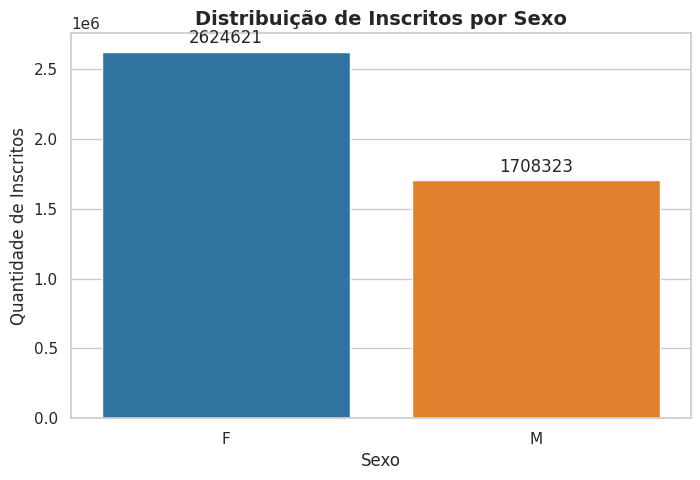

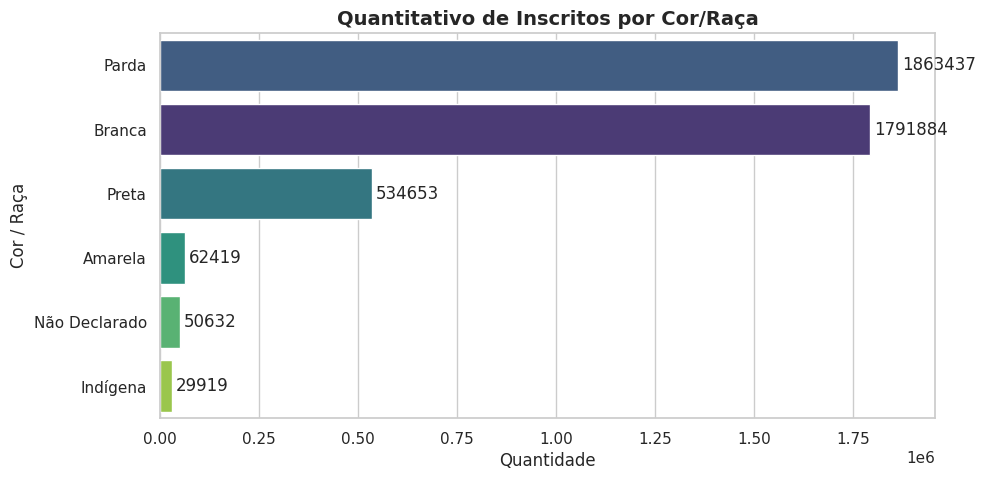

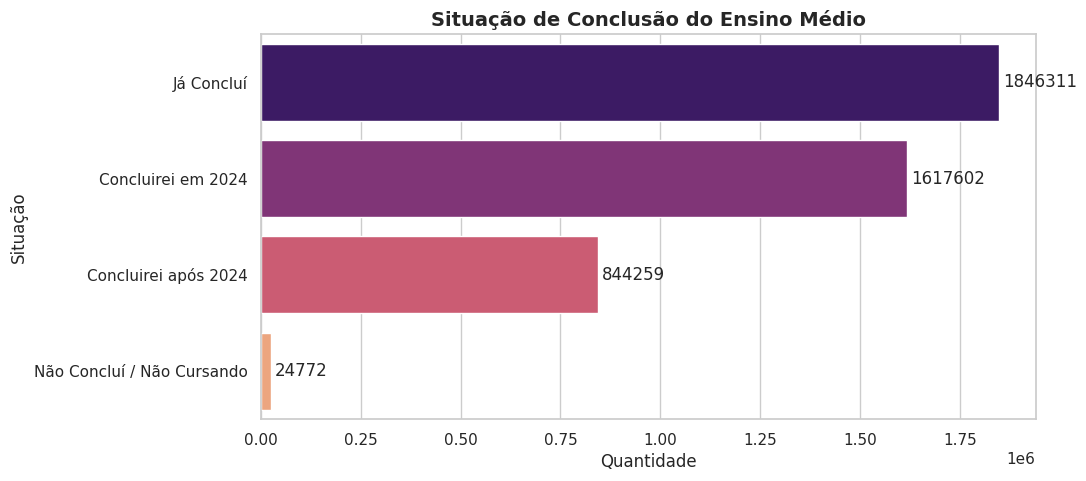

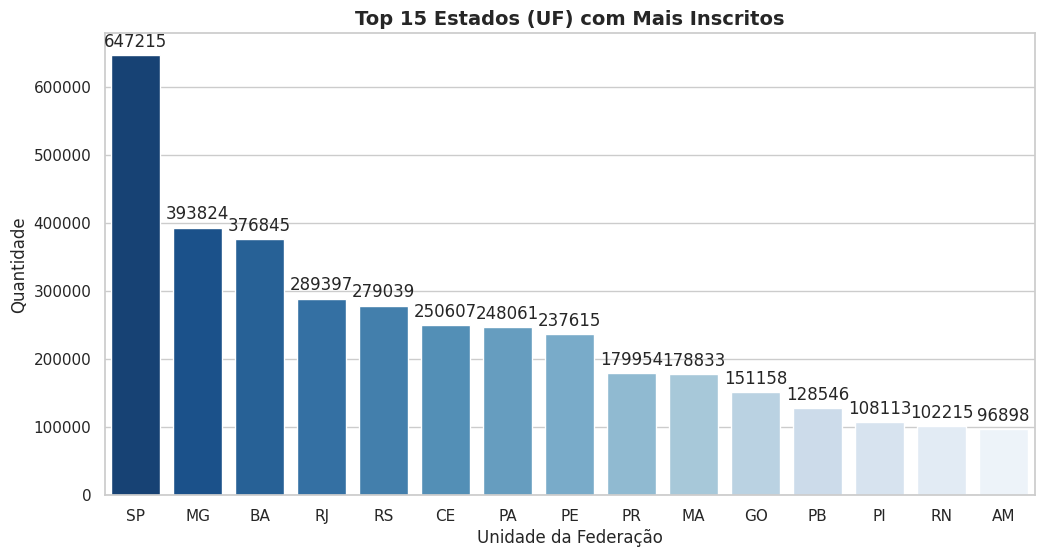

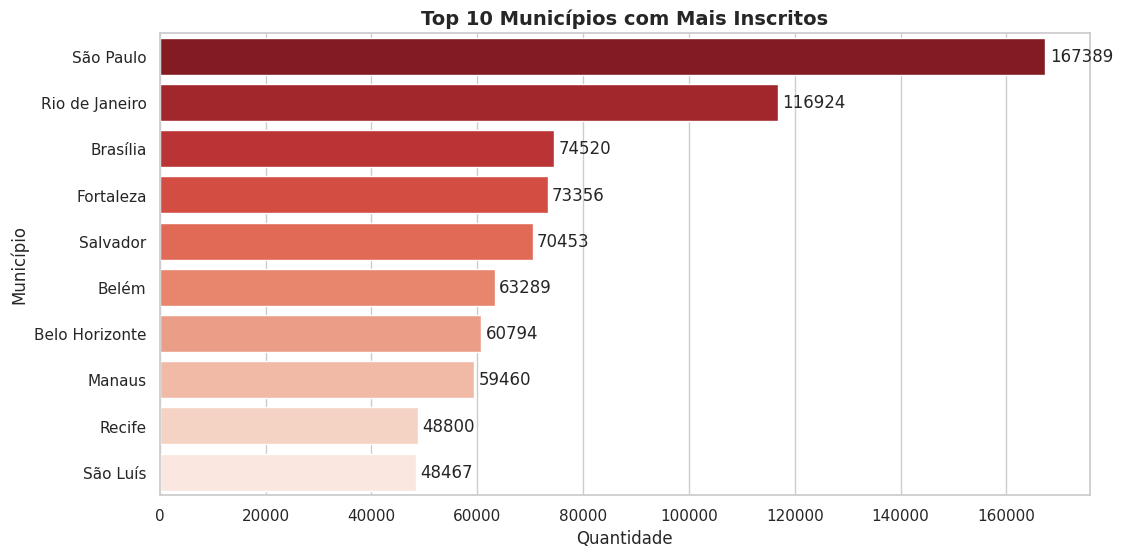

In [32]:
# ==========================================
# [CÉLULA DE CÓDIGO] - Análise Univariada CORRIGIDA (Perfil Demográfico)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

print("Iniciando a Análise Exploratória: Perfil dos Participantes...\n")

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")

# 1. TP_SEXO - Distribuição por Sexo
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_part_limpo, x='TP_SEXO', hue='TP_SEXO', palette=['#1f77b4', '#ff7f0e'], legend=False)
plt.title('Distribuição de Inscritos por Sexo', fontsize=14, fontweight='bold')
plt.xlabel('Sexo', fontsize=12)
plt.ylabel('Quantidade de Inscritos', fontsize=12)
# O loop 'for' garante que todas as barras recebam o número
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)
plt.show()

# 2. TP_COR_RACA - Distribuição por Cor/Raça
mapa_raca = {0: 'Não Declarado', 1: 'Branca', 2: 'Preta', 3: 'Parda', 4: 'Amarela', 5: 'Indígena', 6: 'Sem Info'}
df_part_limpo['DESC_RACA'] = df_part_limpo['TP_COR_RACA'].map(mapa_raca)

plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df_part_limpo, y='DESC_RACA', hue='DESC_RACA', palette='viridis', order=df_part_limpo['DESC_RACA'].value_counts().index, legend=False)
plt.title('Quantitativo de Inscritos por Cor/Raça', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade', fontsize=12)
plt.ylabel('Cor / Raça', fontsize=12)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)
plt.show()

# 3. TP_ST_CONCLUSAO - Situação do Ensino Médio
mapa_conclusao = {1: 'Já Concluí', 2: 'Concluirei em 2024', 3: 'Concluirei após 2024', 4: 'Não Concluí / Não Cursando'}
df_part_limpo['DESC_CONCLUSAO'] = df_part_limpo['TP_ST_CONCLUSAO'].map(mapa_conclusao)

plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df_part_limpo, y='DESC_CONCLUSAO', hue='DESC_CONCLUSAO', palette='magma', order=df_part_limpo['DESC_CONCLUSAO'].value_counts().index, legend=False)
plt.title('Situação de Conclusão do Ensino Médio', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade', fontsize=12)
plt.ylabel('Situação', fontsize=12)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)
plt.show()

# 4. SG_UF_PROVA - Inscrições por Estado (Top 15)
plt.figure(figsize=(12, 6))
top_ufs = df_part_limpo['SG_UF_PROVA'].value_counts().head(15)
ax = sns.barplot(x=top_ufs.index, y=top_ufs.values, hue=top_ufs.index, palette='Blues_r', legend=False)
plt.title('Top 15 Estados (UF) com Mais Inscritos', fontsize=14, fontweight='bold')
plt.xlabel('Unidade da Federação', fontsize=12)
plt.ylabel('Quantidade', fontsize=12)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)
plt.show()

# 5. NO_MUNICIPIO_PROVA - Inscrições por Cidade (Top 10)
plt.figure(figsize=(12, 6))
top_cidades = df_part_limpo['NO_MUNICIPIO_PROVA'].value_counts().head(10)
ax = sns.barplot(y=top_cidades.index, x=top_cidades.values, hue=top_cidades.index, palette='Reds_r', legend=False)
plt.title('Top 10 Municípios com Mais Inscritos', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade', fontsize=12)
plt.ylabel('Município', fontsize=12)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)
plt.show()


### 3. Análise Exploratória: O Impacto Socioeconômico no Desempenho
Com a nossa base agregada por municípios, podemos aplicar técnicas de estatística descritiva e visualização de dados para extrair insights.
1. **Matriz de Correlação:** Avaliamos matematicamente como o aumento do percentual de alunos de baixa renda em uma cidade se correlaciona com as notas médias das provas.
2. **Dispersão e Tendência:** Utilizamos um gráfico de dispersão (Scatter Plot) com uma linha de regressão para ilustrar o impacto direto da renda no desempenho em Matemática, que costuma ser um dos exames mais sensíveis à disparidade educacional.

In [ ]:
# 1. Matriz de Correlação
plt.figure(figsize=(10, 8))
# Selecionando as colunas numéricas de interesse
cols_corr = ['PERC_BAIXA_RENDA', 'FAIXA_ETARIA_MEDIA', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']
matriz_corr = df_cidades[cols_corr].corr()

# Plotando o Heatmap
sns.heatmap(matriz_corr, annot=True, cmap='RdYlBu', center=0, fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação: Renda e Faixa Etária vs Notas Médias', fontsize=14, fontweight='bold')
plt.show()

print("\n" + "="*50 + "\n")

# 2. Scatter Plot (Gráfico de Dispersão com Linha de Tendência)
plt.figure(figsize=(12, 6))
# O regplot traça os pontos e já calcula uma linha de regressão linear
sns.regplot(data=df_cidades, x='PERC_BAIXA_RENDA', y='NU_NOTA_MT',
            scatter_kws={'alpha':0.4, 'color': 'teal', 's': 20},
            line_kws={'color': 'darkred', 'linewidth': 2})

plt.title('Impacto da Baixa Renda no Desempenho em Matemática por Município', fontsize=14, fontweight='bold')
plt.xlabel('Proporção de Alunos de Baixa Renda (0.0 a 1.0)', fontsize=12)
plt.ylabel('Nota Média em Matemática', fontsize=12)
plt.show()

### 4. Engenharia de Variáveis (Feature Engineering)
Para aprofundar a nossa análise e preparar o modelo de *Machine Learning* da Etapa 3, criámos novas métricas (*features*) a partir dos dados originais.
A principal métrica desenvolvida foi a **Taxa de Abstenção Municipal**. Em vez de apenas descartar os alunos faltosos, utilizámos a diferença entre o total de inscrições e o total de presenças efetivas nos dois dias de prova para calcular a percentagem de abstenção de cada município. O objetivo é investigar se a vulnerabilidade económica (baixa renda) também influencia a desistência dos candidatos.


In [ ]:
# ==========================================

print("A calcular a Taxa de Abstenção por município...")

# 1. Total de inscritos por município (da base bruta de Participantes)
total_inscritos = df_part.groupby('CO_MUNICIPIO_PROVA').size().reset_index(name='TOTAL_INSCRITOS')

# 2. Total de presentes por município (da base de Resultados, usando as flags de presença)
# Consideramos "presente" quem compareceu aos dois dias principais
presentes = df_res[(df_res['TP_PRESENCA_CH'] == 1) & (df_res['TP_PRESENCA_MT'] == 1)]
total_presentes = presentes.groupby('CO_MUNICIPIO_PROVA').size().reset_index(name='TOTAL_PRESENTES')

# 3. Cruzar as duas contagens
df_abstencao = pd.merge(total_inscritos, total_presentes, on='CO_MUNICIPIO_PROVA', how='left')

# Preencher com 0 caso algum município extremo não tenha tido qualquer presente
df_abstencao['TOTAL_PRESENTES'] = df_abstencao['TOTAL_PRESENTES'].fillna(0)

# 4. A Mágica do Feature Engineering: Criar a variável derivada
df_abstencao['TAXA_ABSTENCAO'] = 1 - (df_abstencao['TOTAL_PRESENTES'] / df_abstencao['TOTAL_INSCRITOS'])

# 5. Adicionar esta nova variável ao nosso dataset final (Camada Gold)
df_cidades = pd.merge(df_cidades, df_abstencao[['CO_MUNICIPIO_PROVA', 'TAXA_ABSTENCAO']], on='CO_MUNICIPIO_PROVA', how='inner')

print("Feature 'TAXA_ABSTENCAO' criada e integrada com sucesso!")
display(df_cidades[['SG_UF_PROVA', 'TOTAL_CANDIDATOS', 'TAXA_ABSTENCAO', 'NU_NOTA_MT', 'PERC_BAIXA_RENDA']].head())

In [ ]:
# Visualização do Feature Engineering

plt.figure(figsize=(12, 6))
# Plot da relação entre Baixa Renda e a nova variável de Abstenção
sns.regplot(data=df_cidades, x='PERC_BAIXA_RENDA', y='TAXA_ABSTENCAO',
            scatter_kws={'alpha':0.4, 'color': 'purple', 's': 20},
            line_kws={'color': 'orange', 'linewidth': 2})

plt.title('Relação entre Baixa Renda e a Taxa de Abstenção Municipal', fontsize=14, fontweight='bold')
plt.xlabel('Proporção de Alunos de Baixa Renda (0.0 a 1.0)', fontsize=12)
plt.ylabel('Taxa de Abstenção (0.0 a 1.0)', fontsize=12)
plt.show()

### 5. Camada Gold: Preparação para Machine Learning (Etapa 3)
Para garantir que o algoritmo de clusterização (K-Means) que será aplicado na Etapa 3 funcione corretamente, precisamos padronizar as variáveis numéricas. Como as notas variam de 0 a 1000 e as taxas (renda e abstenção) variam de 0 a 1, o algoritmo daria um peso desproporcional às notas. Utilizaremos o `StandardScaler` para transformar os dados em *Z-scores*, colocando todas as variáveis na mesma escala de importância.



In [ ]:
# ==========================================
# Padronização (Scaling)
# ==========================================

print("Preparando a Camada Gold (Padronização de Variáveis)...")

# Selecionamos as variáveis numéricas vitais para o modelo
cols_para_padronizar = ['PERC_BAIXA_RENDA', 'TAXA_ABSTENCAO', 'FAIXA_ETARIA_MEDIA',
                        'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']

# Inicializamos o padronizador
scaler = StandardScaler()

# Criamos o dataset final da Camada Gold
df_cidades_gold = df_cidades.copy()

# Aplicamos a transformação matemática
df_cidades_gold[cols_para_padronizar] = scaler.fit_transform(df_cidades_gold[cols_para_padronizar])

print("✅ Variáveis padronizadas com sucesso! O dataset está pronto para o modelo de Clusterização.")
display(df_cidades_gold[['SG_UF_PROVA', 'PERC_BAIXA_RENDA', 'TAXA_ABSTENCAO', 'NU_NOTA_MT']].head())